In [1]:
from typing import Tuple, List, Dict, Any
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

In [2]:
DF_PATH = "data.csv"
DF_NO_AUG_PATH = "data_no_aug.csv"

In [3]:
assert os.path.exists(DF_PATH), f"Está faltando o arquivo {DF_PATH}. Rode primeiramente o notebook `analysis.ipynb` para criá-lo"
assert os.path.exists(DF_NO_AUG_PATH), f"Está faltando o arquivo {DF_NO_AUG_PATH}. Rode primeiramente o notebook `analysis.ipynb` para criá-lo"

In [4]:
RANDOM_STATE = 42
LABELS = ["Air temperature [K]", "Nm_Min", "Nm_RPM"]
TARGET = 'Failure Type'

In [5]:
def setup_data(df_path:str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, List[str]]:
    data = pd.read_csv(df_path)
    
    encoder = LabelEncoder()
    encoded_target = encoder.fit_transform(data[TARGET])

    print("Classes: ", encoder.classes_)
    print("Classes Encoded: ", np.unique(encoded_target))

    data[TARGET] = encoded_target

    X = data[LABELS]
    Y = data[TARGET]
    
    test_size = 0.2
    
    print(f"Realizando Holdout Estratificado para gerar dados de treino e teste | {test_size*100:.2f}% Para Teste")
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=RANDOM_STATE)

    return (X_train, X_test, y_train, y_test, encoder.classes_)

In [6]:
def create_models() -> Dict[str, Any]:
    print("Criando modelos padrão")
    models = {
        "Árvore de Decisão": {
            "model":DecisionTreeClassifier(random_state=RANDOM_STATE),
        },
        "Modelo Baseado em Bagging": {
            "model": BaggingClassifier(random_state=RANDOM_STATE),
        },
        "AdaBoost": {
            "model":AdaBoostClassifier(random_state=RANDOM_STATE),
        },
        "Random Forest": {
            "model":RandomForestClassifier(random_state=RANDOM_STATE)
        }
    }

    return models

In [7]:
def eval_model(pred:np.ndarray, true:np.ndarray, model_name:str, encoded_labels:List[str]) -> Dict[str,float]:
    print(classification_report(true, pred, zero_division=0))

    cm = confusion_matrix(true, pred)
    df_cm = pd.DataFrame(cm, index=encoded_labels, columns=encoded_labels)
    
    sns.heatmap(df_cm, annot=True, fmt=".0f", cmap="coolwarm")
    plt.title(f"Matrix de confusão - {model_name}")
    plt.show()

    precision = precision_score(true, pred, average="macro")
    recall = recall_score(true, pred, average="macro")
    f1 = f1_score(true, pred, average="macro")
    accuracy = accuracy_score(true, pred)

    print("Métricas Manuais (AVG = Macro)")
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1 Score: ", f1)
    print("Accuracy: ", accuracy)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }

In [8]:
def show_matrix_table(models_data_dict:Dict[str,Any]):
    metrics_df = pd.DataFrame(columns=("model", "f1", "precision", "recall", "accuracy"))

    for name, model_data in models_data_dict.items():
        row = {
            "model":name,
        }
        
        for metric,val in models_data_dict[name]["test_metrics"].items():
            row[metric] = val
    
        metrics_df.loc[len(metrics_df)] = row
    
    print("resultados gerais: ")
    display(metrics_df)

In [9]:
def run_models_for_df(df_path:str) -> Dict[str,Any]:
    X_train, X_test, y_train, y_test,encoded_labels = setup_data(df_path)
    print("-"*80)
    print(f"Tamanho Treino: {X_train.shape[0]}") 
    print(f"Tamanho Teste: {X_test.shape[0]}") 
    print("-"*80)
    
    models = create_models()
    
    for name, model_data in models.items():
        model = model_data["model"]
        
        print(f"Treinando moelo `{name}` ...")
        model.fit(X_train, y_train)
        
        print("Realizando a predição sobre os dados de teste...")
        y_pred = model.predict(X_test)
        models[name]["pred_test"] = y_pred

    for name, model_data in models.items():
        print(f"modelo: {name}")
        metrics = eval_model(model_data["pred_test"], y_test, name, encoded_labels)
        models[name]["test_metrics"] = metrics
        print("-"*80)

    show_matrix_table(models)

    return models

Classes:  ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Tool Wear Failure']
Classes Encoded:  [0 1 2 3 4]
Realizando Holdout Estratificado para gerar dados de treino e teste | 20.00% Para Teste
--------------------------------------------------------------------------------
Tamanho Treino: 15429
Tamanho Teste: 3858
--------------------------------------------------------------------------------
Criando modelos padrão
Treinando moelo `Árvore de Decisão` ...
Realizando a predição sobre os dados de teste...
Treinando moelo `Modelo Baseado em Bagging` ...
Realizando a predição sobre os dados de teste...
Treinando moelo `AdaBoost` ...
Realizando a predição sobre os dados de teste...
Treinando moelo `Random Forest` ...
Realizando a predição sobre os dados de teste...
modelo: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       482
           1       0.99      0.97      0.98      1929
     

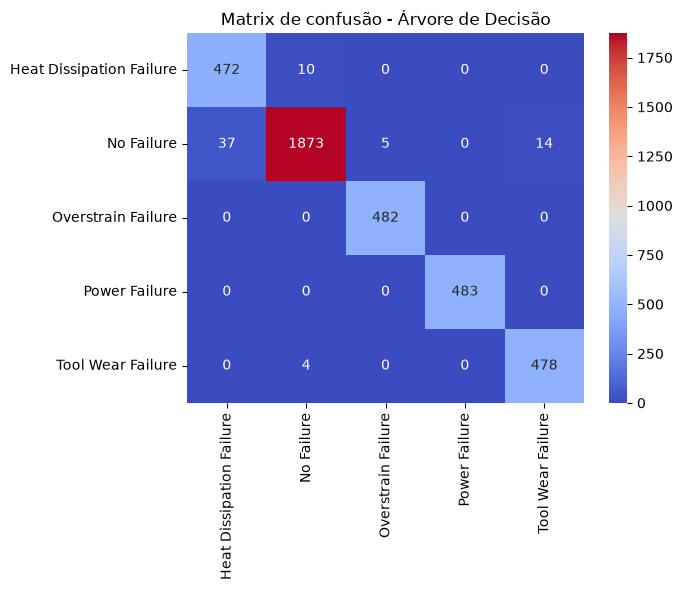

Métricas Manuais (AVG = Macro)
Precision:  0.9762334078085537
Recall:  0.9883847542101447
F1 Score:  0.9821177782757466
Accuracy:  0.9818558838776568
--------------------------------------------------------------------------------
modelo: Modelo Baseado em Bagging
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       482
           1       1.00      0.97      0.99      1929
           2       0.99      1.00      0.99       482
           3       1.00      1.00      1.00       483
           4       0.99      1.00      0.99       482

    accuracy                           0.99      3858
   macro avg       0.98      0.99      0.99      3858
weighted avg       0.99      0.99      0.99      3858



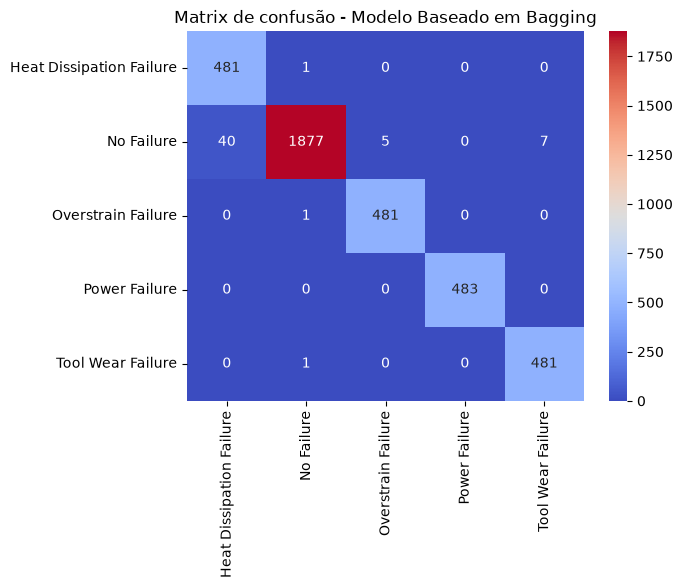

Métricas Manuais (AVG = Macro)
Precision:  0.9793992990637281
Recall:  0.9933637922170668
F1 Score:  0.9860474753773184
Accuracy:  0.985743908761016
--------------------------------------------------------------------------------
modelo: AdaBoost
              precision    recall  f1-score   support

           0       0.63      0.65      0.64       482
           1       0.76      0.94      0.84      1929
           2       0.88      1.00      0.94       482
           3       1.00      0.90      0.95       483
           4       0.00      0.00      0.00       482

    accuracy                           0.79      3858
   macro avg       0.65      0.70      0.67      3858
weighted avg       0.69      0.79      0.74      3858



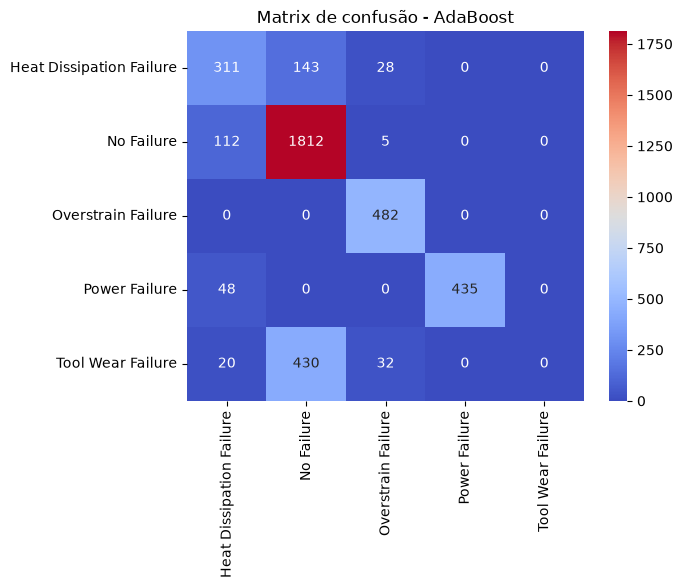

/home/alexandre/projects/mestrado-aulas/mineracao-de-dados/atividades/atividade1/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Métricas Manuais (AVG = Macro)
Precision:  0.6548639335900837
Recall:  0.6970392291199305
F1 Score:  0.6727719894572779
Accuracy:  0.7879730430274754
--------------------------------------------------------------------------------
modelo: Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       482
           1       1.00      0.99      0.99      1929
           2       0.99      1.00      0.99       482
           3       1.00      1.00      1.00       483
           4       0.99      1.00      0.99       482

    accuracy                           0.99      3858
   macro avg       0.99      1.00      0.99      3858
weighted avg       0.99      0.99      0.99      3858



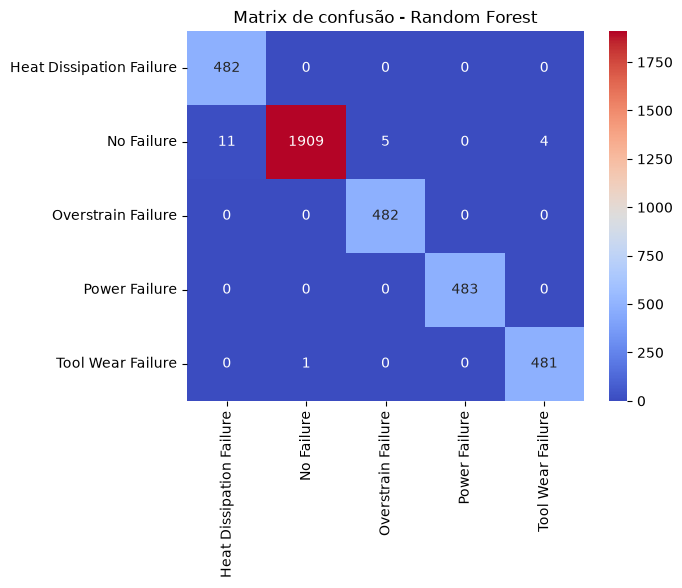

Métricas Manuais (AVG = Macro)
Precision:  0.9917299406866533
Recall:  0.9975114489695389
F1 Score:  0.9945834369312087
Accuracy:  0.994556765163297
--------------------------------------------------------------------------------
resultados gerais: 


,model,f1,precision,recall,accuracy
0,Árvore de Decisão,0.982118,0.976233,0.988385,0.981856
1,Modelo Baseado em Bagging,0.986047,0.979399,0.993364,0.985744
2,AdaBoost,0.672772,0.654864,0.697039,0.787973
3,Random Forest,0.994583,0.991730,0.997511,0.994557


In [10]:
models1 = run_models_for_df(DF_PATH)

Random Forest foi o modelo que teve os melhores resultados perante as métricas usadas

## Setagem de hiper-paramêtros

In [11]:
params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2,3,5,10,20,50],
    'random_state':[RANDOM_STATE]
}

In [12]:
X_train, X_test, y_train, y_test,encoded_labels = setup_data(DF_PATH)
rf = RandomForestClassifier()
gs = GridSearchCV(rf, params, refit=True, cv=5, return_train_score=True)
gs.fit(X_train, y_train)

Classes:  ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Tool Wear Failure']
Classes Encoded:  [0 1 2 3 4]
Realizando Holdout Estratificado para gerar dados de treino e teste | 20.00% Para Teste


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'random_state': [42]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.

In [13]:
gs.cv_results_

{'mean_fit_time': array([0.34531512, 0.40187092, 0.53521953, 0.77334604, 0.88679743,
        0.93005428, 0.43816729, 0.54532671, 0.79326587, 1.08203001,
        1.17214003, 1.17740984, 0.42674975, 0.54173408, 0.76041131,
        1.03873935, 1.19162841, 1.29074526]),
 'std_fit_time': array([0.01398373, 0.00836501, 0.01948582, 0.01073775, 0.01277111,
        0.03245771, 0.01289738, 0.01536726, 0.02615031, 0.01913406,
        0.00858776, 0.01539763, 0.00931123, 0.0102634 , 0.00859951,
        0.01659969, 0.05685821, 0.03208921]),
 'mean_score_time': array([0.01539001, 0.01640997, 0.02049308, 0.02786341, 0.03264394,
        0.03379874, 0.01545777, 0.01765542, 0.02144728, 0.0289134 ,
        0.0326663 , 0.03293948, 0.01515779, 0.01711154, 0.02132154,
        0.02797394, 0.03290014, 0.03475933]),
 'std_score_time': array([4.79198797e-04, 1.03304501e-04, 8.92385746e-04, 2.60464309e-04,
        4.30403584e-05, 1.22353872e-03, 4.99961034e-04, 8.55919304e-04,
        5.19610276e-04, 9.49299165e-

In [14]:
print("Melhor modelo na busca: ", gs.best_estimator_)
print("Melhores parâmetros: ", gs.best_params_)

Melhor modelo na busca:  RandomForestClassifier(max_depth=50, random_state=42)
Melhores parâmetros:  {'criterion': 'gini', 'max_depth': 50, 'random_state': 42}


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       482
           1       1.00      0.99      0.99      1929
           2       0.99      1.00      0.99       482
           3       1.00      1.00      1.00       483
           4       0.99      1.00      0.99       482

    accuracy                           0.99      3858
   macro avg       0.99      1.00      0.99      3858
weighted avg       0.99      0.99      0.99      3858



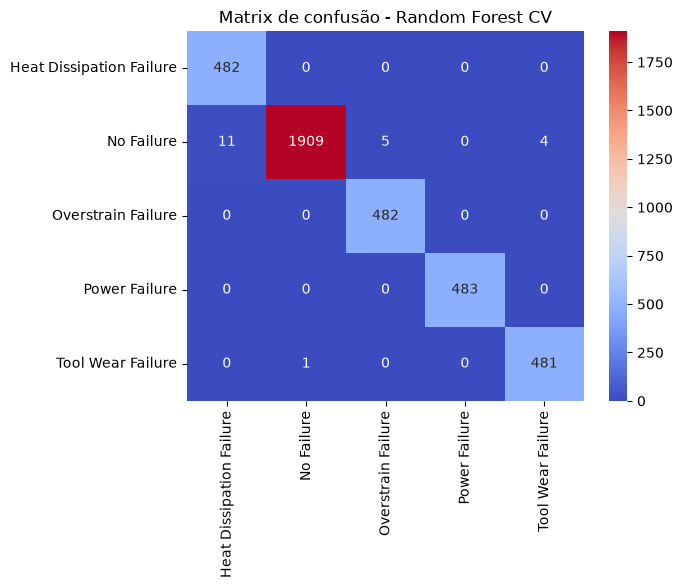

Métricas Manuais (AVG = Macro)
Precision:  0.9917299406866533
Recall:  0.9975114489695389
F1 Score:  0.9945834369312087
Accuracy:  0.994556765163297


{'precision': 0.9917299406866533,
 'recall': 0.9975114489695389,
 'f1': 0.9945834369312087,
 'accuracy': 0.994556765163297}

In [16]:
model = gs.best_estimator_
cv_pred = model.predict(X_test)
eval_model(cv_pred,y_test,"Random Forest CV", encoded_labels)

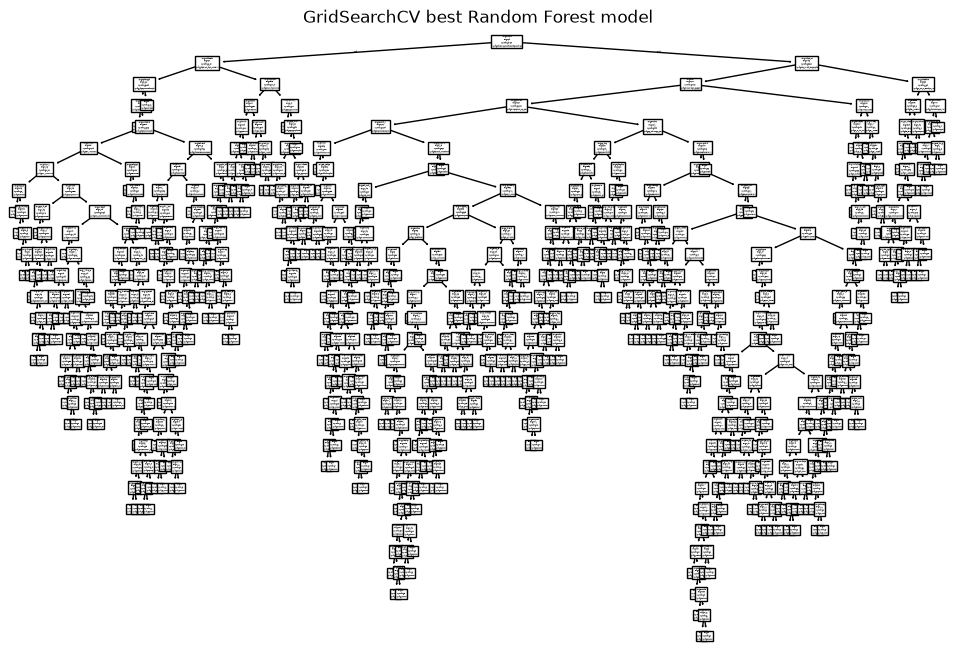

In [17]:
plt.figure(figsize=(12, 8))
plot_tree(model.estimators_[0])
plt.title("GridSearchCV best Random Forest model")
plt.show()

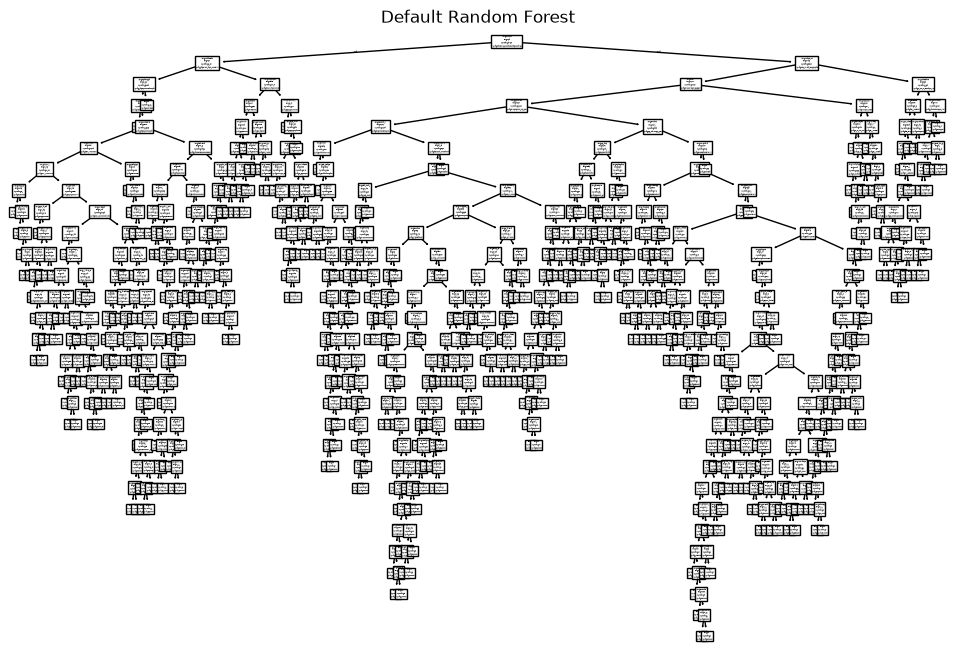

In [18]:
plt.figure(figsize=(12, 8))
plot_tree(models1["Random Forest"]["model"].estimators_[0])
plt.title("Default Random Forest")
plt.show()

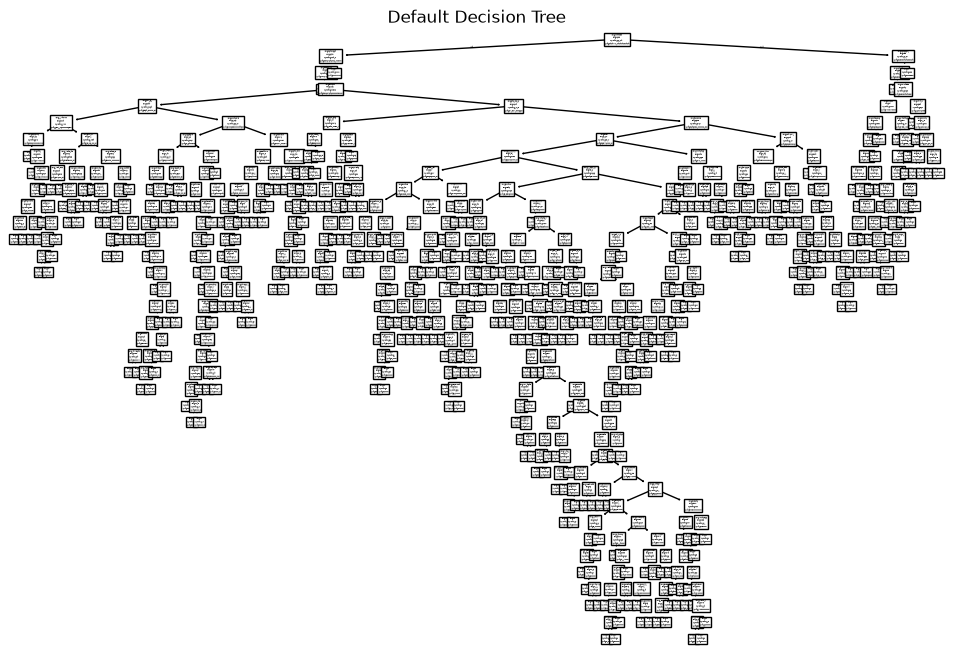

In [19]:
plt.figure(figsize=(12, 8))
plot_tree(models1["Árvore de Decisão"]["model"])
plt.title("Default Decision Tree")
plt.show()

Os modelos podem estar aprendendo o que vimos anteriormente na análise, mas também podem estar achando padrões menores. Talvez, estes podem ser devidos aos ruídos adicionados. Vamos testar a versão sem data augmentation

Classes:  ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Tool Wear Failure']
Classes Encoded:  [0 1 2 3 4]
Realizando Holdout Estratificado para gerar dados de treino e teste | 20.00% Para Teste
--------------------------------------------------------------------------------
Tamanho Treino: 7978
Tamanho Teste: 1995
--------------------------------------------------------------------------------
Criando modelos padrão
Treinando moelo `Árvore de Decisão` ...
Realizando a predição sobre os dados de teste...
Treinando moelo `Modelo Baseado em Bagging` ...
Realizando a predição sobre os dados de teste...
Treinando moelo `AdaBoost` ...
Realizando a predição sobre os dados de teste...
Treinando moelo `Random Forest` ...
Realizando a predição sobre os dados de teste...
modelo: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.12      0.14      0.13        22
           1       0.99      0.98      0.98      1929
      

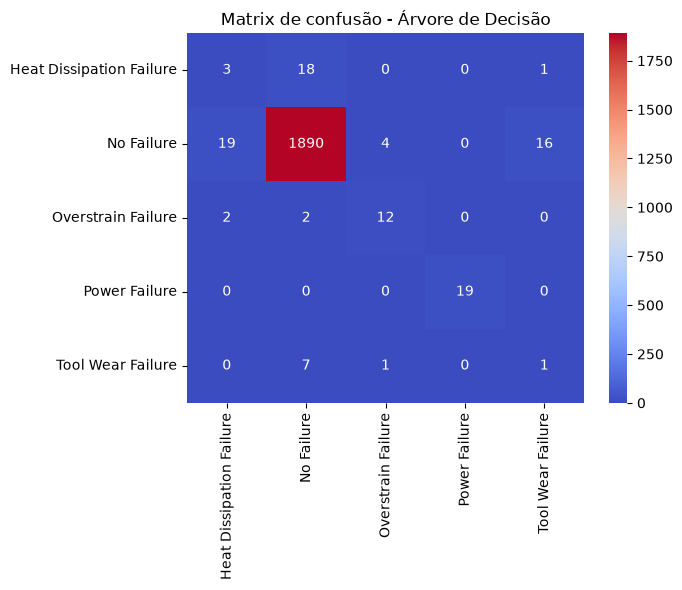

Métricas Manuais (AVG = Macro)
Precision:  0.5744706802908957
Recall:  0.5954514036162559
F1 Score:  0.582924179505608
Accuracy:  0.9649122807017544
--------------------------------------------------------------------------------
modelo: Modelo Baseado em Bagging
              precision    recall  f1-score   support

           0       0.11      0.05      0.06        22
           1       0.98      0.99      0.99      1929
           2       0.68      0.81      0.74        16
           3       1.00      1.00      1.00        19
           4       0.00      0.00      0.00         9

    accuracy                           0.98      1995
   macro avg       0.56      0.57      0.56      1995
weighted avg       0.97      0.98      0.97      1995



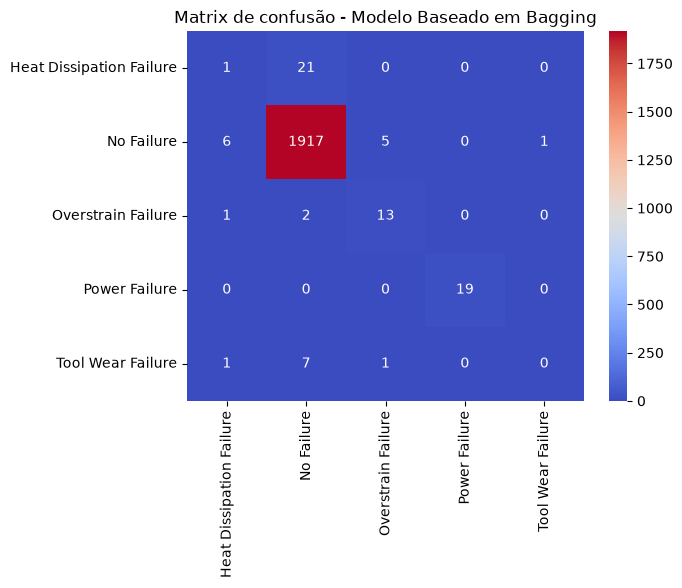

Métricas Manuais (AVG = Macro)
Precision:  0.5559826633867668
Recall:  0.5703467411282341
F1 Score:  0.5593074717153416
Accuracy:  0.9774436090225563
--------------------------------------------------------------------------------
modelo: AdaBoost
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.98      1.00      0.99      1929
           2       0.70      0.88      0.78        16
           3       0.94      0.89      0.92        19
           4       0.00      0.00      0.00         9

    accuracy                           0.98      1995
   macro avg       0.53      0.55      0.54      1995
weighted avg       0.96      0.98      0.97      1995



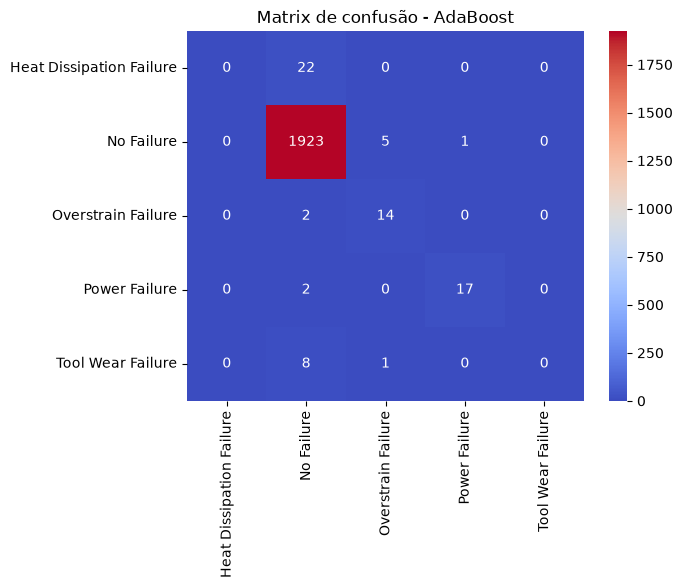

/home/alexandre/projects/mestrado-aulas/mineracao-de-dados/atividades/atividade1/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Métricas Manuais (AVG = Macro)
Precision:  0.5254141827059557
Recall:  0.5533252844397152
F1 Score:  0.5372806671828803
Accuracy:  0.9794486215538847
--------------------------------------------------------------------------------
modelo: Random Forest
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.98      1.00      0.99      1929
           2       0.64      0.88      0.74        16
           3       0.95      1.00      0.97        19
           4       0.00      0.00      0.00         9

    accuracy                           0.98      1995
   macro avg       0.51      0.57      0.54      1995
weighted avg       0.97      0.98      0.97      1995



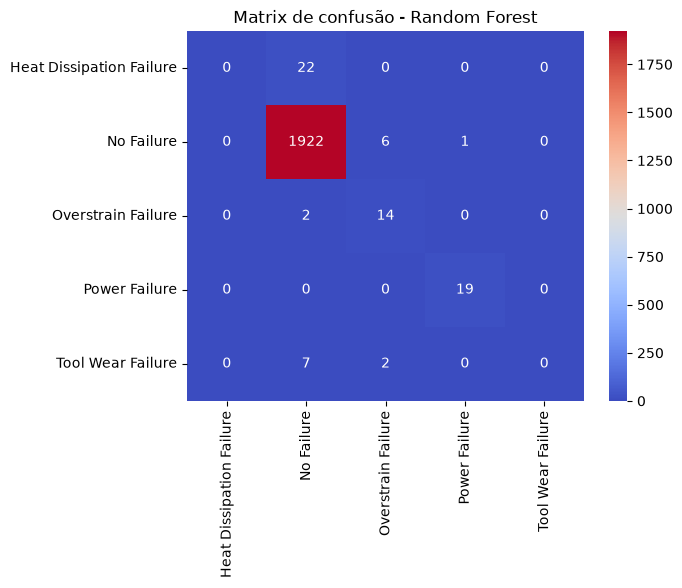

Métricas Manuais (AVG = Macro)
Precision:  0.514098124098124
Recall:  0.5742742353551062
F1 Score:  0.5402824621892384
Accuracy:  0.9799498746867168
--------------------------------------------------------------------------------
resultados gerais: 


/home/alexandre/projects/mestrado-aulas/mineracao-de-dados/atividades/atividade1/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,f1,precision,recall,accuracy
0,Árvore de Decisão,0.582924,0.574471,0.595451,0.964912
1,Modelo Baseado em Bagging,0.559307,0.555983,0.570347,0.977444
2,AdaBoost,0.537281,0.525414,0.553325,0.979449
3,Random Forest,0.540282,0.514098,0.574274,0.979950


In [20]:
models2 = run_models_for_df(DF_NO_AUG_PATH)

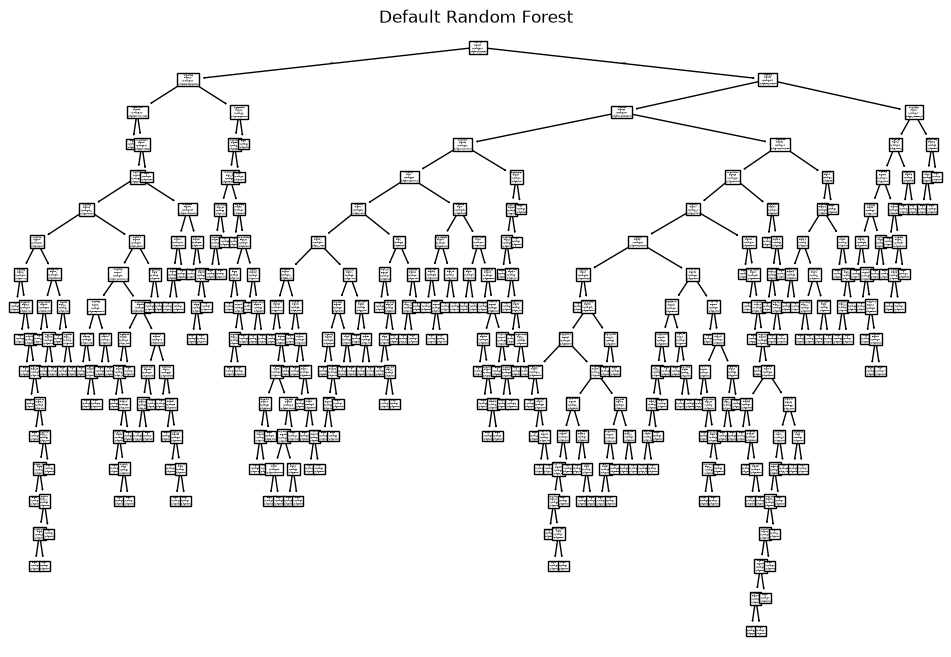

In [27]:
plt.figure(figsize=(12, 8))
plot_tree(models2["Random Forest"]["model"].estimators_[0])
plt.title("Default Random Forest")
plt.show()

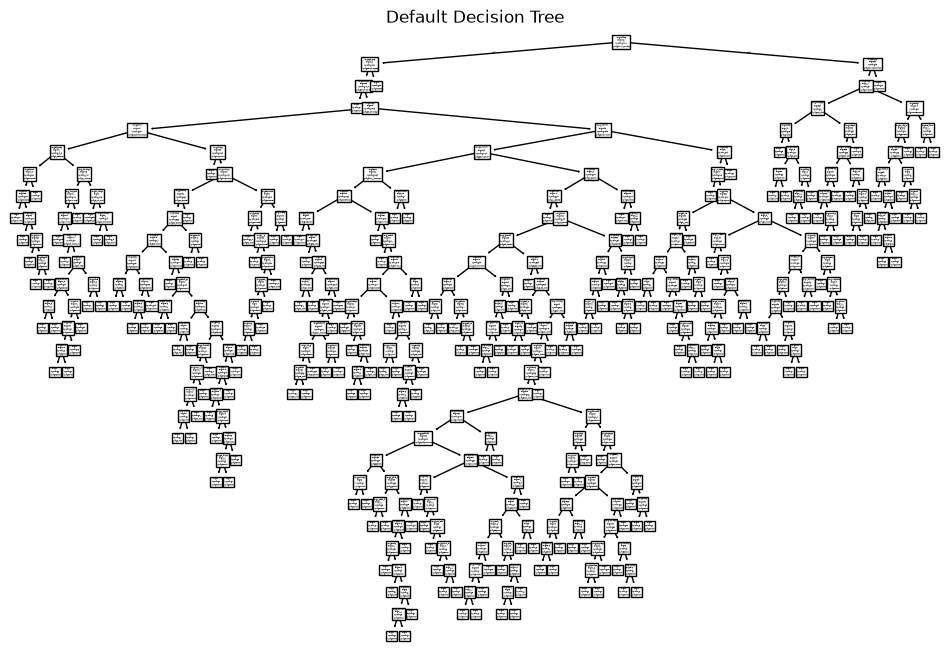

In [28]:
plt.figure(figsize=(12, 8))
plot_tree(models2["Árvore de Decisão"]["model"])
plt.title("Default Decision Tree")
plt.show()

Neste caso, o modelo acaba ficando mais fraco já que os dados não estão devidamente balanceados

## Teste OVA E OVO

In [21]:
def generate_bin_models() -> Tuple[List[Any], List[str]]:
    ovo = OneVsOneClassifier(
        DecisionTreeClassifier(random_state=RANDOM_STATE)
    )
    ovr = OneVsRestClassifier(
        DecisionTreeClassifier(random_state=RANDOM_STATE)
    )

    return ([ovo,ovr], ["ovo", "ovr"])

In [24]:
def run_bin_model_for_df(df_path:str):
    X_train, X_test, y_train, y_test,encoded_labels = setup_data(df_path)
    models,names = generate_bin_models()
    output_table = pd.DataFrame(columns=("model", "precision", "recall", "f1", "accuracy"))
    
    for i,(name,model) in enumerate(zip(names,models)):
        print(f"Treinando modelo {name} ...")
        model.fit(X_train,y_train)
        print("Realizando predição...")
        pred = model.predict(X_test)
        
    
        outcome = eval_model(pred,y_test,name,encoded_labels)
        output_table.loc[i] = {**outcome, "model":name}
    
    display(output_table)

Classes:  ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Tool Wear Failure']
Classes Encoded:  [0 1 2 3 4]
Realizando Holdout Estratificado para gerar dados de treino e teste | 20.00% Para Teste
Treinando modelo ovo ...
Realizando predição...
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       482
           1       1.00      0.97      0.98      1929
           2       1.00      1.00      1.00       482
           3       1.00      1.00      1.00       483
           4       0.98      1.00      0.99       482

    accuracy                           0.98      3858
   macro avg       0.98      0.99      0.99      3858
weighted avg       0.99      0.98      0.99      3858



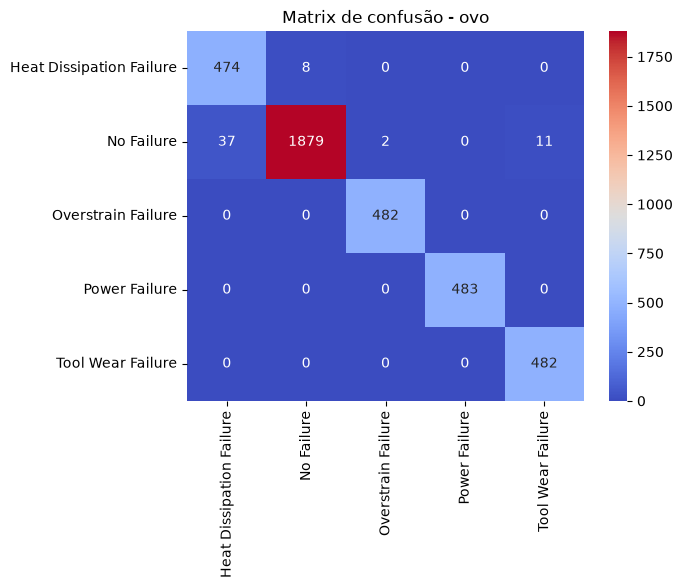

Métricas Manuais (AVG = Macro)
Precision:  0.9793817633417612
Recall:  0.9914964647474989
F1 Score:  0.9852262346747649
Accuracy:  0.9849663037843442
Treinando modelo ovr ...
Realizando predição...
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       482
           1       1.00      0.97      0.98      1929
           2       0.99      1.00      1.00       482
           3       1.00      1.00      1.00       483
           4       0.99      0.99      0.99       482

    accuracy                           0.98      3858
   macro avg       0.98      0.99      0.98      3858
weighted avg       0.98      0.98      0.98      3858



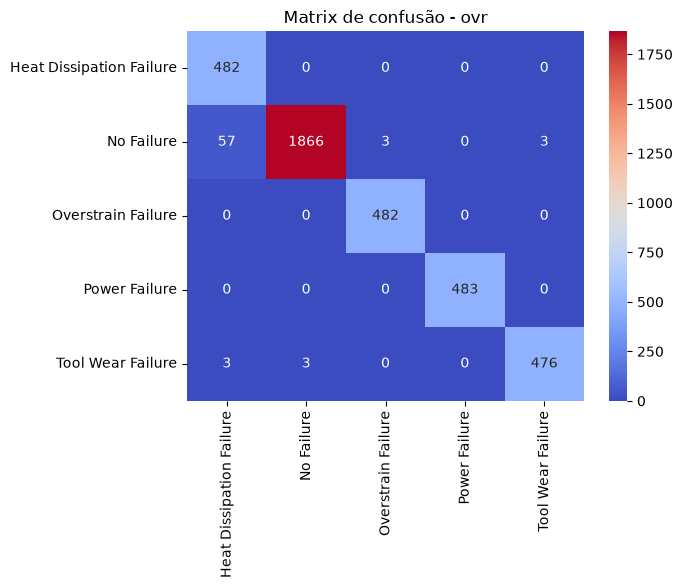

Métricas Manuais (AVG = Macro)
Precision:  0.9750490283050646
Recall:  0.9909784916399399
F1 Score:  0.9823122119664566
Accuracy:  0.9821150855365475


,model,precision,recall,f1,accuracy
0,ovo,0.979382,0.991496,0.985226,0.984966
1,ovr,0.975049,0.990978,0.982312,0.982115


In [25]:
run_bin_model_for_df(DF_PATH)

Ambos os modelos se saem bem, mas OVO apresentou valores ligeiramente melhores

Classes:  ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Tool Wear Failure']
Classes Encoded:  [0 1 2 3 4]
Realizando Holdout Estratificado para gerar dados de treino e teste | 20.00% Para Teste
Treinando modelo ovo ...
Realizando predição...
              precision    recall  f1-score   support

           0       0.14      0.09      0.11        22
           1       0.99      0.99      0.99      1929
           2       0.70      0.88      0.78        16
           3       0.95      1.00      0.97        19
           4       0.00      0.00      0.00         9

    accuracy                           0.97      1995
   macro avg       0.56      0.59      0.57      1995
weighted avg       0.97      0.97      0.97      1995



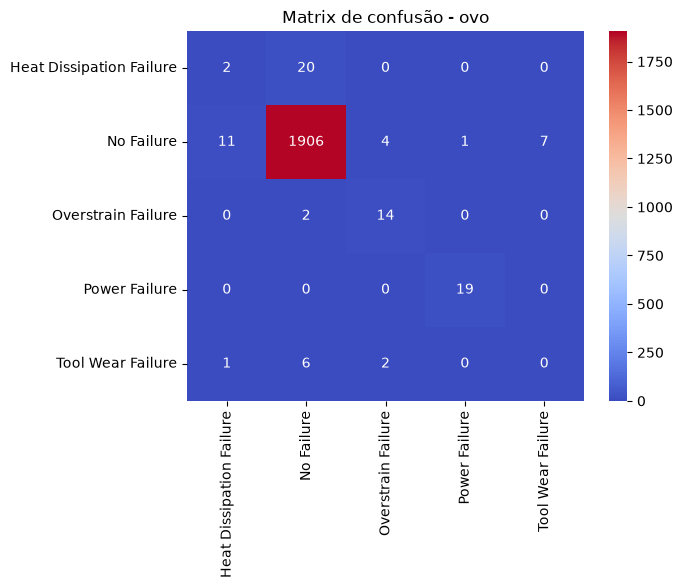

Métricas Manuais (AVG = Macro)
Precision:  0.5556758753139311
Recall:  0.5907971629200246
F1 Score:  0.5700091377544135
Accuracy:  0.9729323308270676
Treinando modelo ovr ...
Realizando predição...
              precision    recall  f1-score   support

           0       0.07      0.14      0.09        22
           1       0.99      0.97      0.98      1929
           2       0.71      0.75      0.73        16
           3       1.00      1.00      1.00        19
           4       0.14      0.11      0.12         9

    accuracy                           0.96      1995
   macro avg       0.58      0.59      0.58      1995
weighted avg       0.97      0.96      0.96      1995



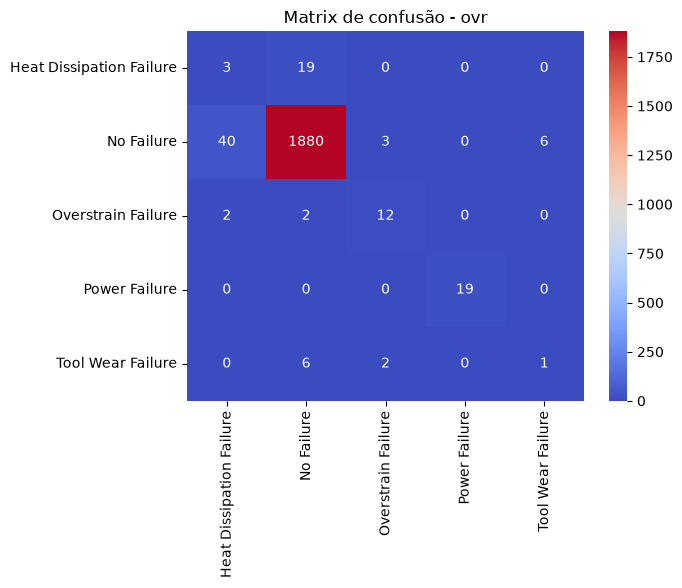

Métricas Manuais (AVG = Macro)
Precision:  0.580249559708519
Recall:  0.5944145969806934
F1 Score:  0.5844025323189721
Accuracy:  0.9598997493734336


,model,precision,recall,f1,accuracy
0,ovo,0.555676,0.590797,0.570009,0.972932
1,ovr,0.580250,0.594415,0.584403,0.959900


In [26]:
run_bin_model_for_df(DF_NO_AUG_PATH)